In [8]:
import numpy as np
from scipy.stats import gamma
from sklearn.cluster import KMeans
from scipy.linalg import eigh
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from PIL import Image
from prosirenje import prosiri_laplacian_piramida 

In [9]:
def ng_beva(X, max_iter=50, gamma_val=1.25, tol=1e-6):
    """
    NG BEVA - Background Parameter Estimation

    Parameters:
        X : ndarray (N x p)  -> ulazni podaci (pikseli)
        max_iter : int       -> maksimalan broj iteracija
        gamma_val : float    -> parametar γ
        tol : float          -> tolerancija za zaustavljanje

    Returns:
        dict sa procijenjenim parametrima
    """

    N, p = X.shape

    # Inicijalizacija
    A_c = np.zeros((0, p))        # anomalije
    B_c = X.copy()                # background
    w = np.ones(len(B_c))         # težine
    d0 = np.sqrt(p) + np.sqrt(2)  # prag
    i = 0

    while i < max_iter and len(B_c) > 0:

        # 1. Robustna procjena sredine i kovarijanse
        w_sum = np.sum(w)
        mu = np.sum(w[:, None] * B_c, axis=0) / w_sum

        diff = B_c - mu
        Sigma = (diff.T @ (w[:, None] * diff)) / (np.sum(w**2) - 1)

        # Regularizacija (numerička stabilnost)
        Sigma += 1e-6 * np.eye(p)
        Sigma_inv = np.linalg.inv(Sigma)

        # 2. Mahalanobis distance
        d = np.array([
            (x - mu).T @ Sigma_inv @ (x - mu)
            for x in B_c
        ])

        # 3. Update težina
        w_new = np.where(
            d <= d0,
            1,
            (d0 / d) * np.exp(-0.5 * ((d - d0)**2) / (gamma_val**2))
        )

        # 4. Gamma fitting (MLE)
        k_hat, loc, theta_hat = gamma.fit(d, floc=0)

        # 5. Update skupova
        # prag τᶦ (možeš ga prilagoditi, npr. percentil)
        tau = gamma.ppf(0.99, k_hat, scale=theta_hat)

        idx = np.where(d >= tau)[0]

        if len(idx) == 0:
            break

        A_c = np.vstack([A_c, B_c[idx]])
        B_c = np.delete(B_c, idx, axis=0)
        w = np.delete(w_new, idx)

        i += 1

        # Stopping kriterij
        if len(idx) < tol:
            break

    return {
        "A_c": A_c,
        "B_c": B_c,
        "mu": mu,
        "Sigma": Sigma,
        "k_hat": k_hat,
        "theta_hat": theta_hat
    }

In [16]:
import numpy as np
from scipy.linalg import eigh
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel


def clustering_nystrom(X, L=3, sigma=1.0, m=500):
    """
    Spectral clustering using Nyström approximation.

    Parameters
    ----------
    X : ndarray (N x p)
        Data matrix

    L : int
        Number of clusters

    sigma : float
        RBF kernel scale

    m : int
        Number of landmark points

    Returns
    -------
    labels : ndarray (N,)
        Cluster assignments
    """

    N = X.shape[0]

    # ---------------------------------------------------------
    # 1. Random landmark selection
    # ---------------------------------------------------------
    landmark_idx = np.random.choice(N, m, replace=False)

    X_landmarks = X[landmark_idx]

    # ---------------------------------------------------------
    # 2. Compute A matrix (m x m)
    # ---------------------------------------------------------
    #
    # Similarity among landmarks
    #
    gamma = 1.0 / (2.0 * sigma**2)

    A = rbf_kernel(
        X_landmarks,
        X_landmarks,
        gamma=gamma
    )

    # Stabilization
    A += 1e-8 * np.eye(m)

    # ---------------------------------------------------------
    # 3. Compute B matrix (m x N)
    # ---------------------------------------------------------
    #
    # Similarity between landmarks and ALL points
    #
    B = rbf_kernel(
        X_landmarks,
        X,
        gamma=gamma
    )

    # ---------------------------------------------------------
    # 4. Eigendecomposition of A only
    # ---------------------------------------------------------
    eigvals, eigvecs = eigh(A)

    # Take largest L eigenvalues
    eigvals = eigvals[-L:]
    eigvecs = eigvecs[:, -L:]

    # Numerical stability
    eigvals = np.maximum(eigvals, 1e-8)

    # ---------------------------------------------------------
    # 5. Nyström extension
    # ---------------------------------------------------------
    #
    # Approximate eigenvectors for ALL points
    #
    V = B.T @ eigvecs @ np.diag(1.0 / np.sqrt(eigvals))

    # ---------------------------------------------------------
    # 6. Row normalization
    # ---------------------------------------------------------
    norms = np.linalg.norm(V, axis=1, keepdims=True) + 1e-8
    V_norm = V / norms

    # ---------------------------------------------------------
    # 7. KMeans in spectral space
    # ---------------------------------------------------------
    kmeans = KMeans(
        n_clusters=L,
        n_init=10,
        random_state=0
    )

    labels = kmeans.fit_predict(V_norm)

    return labels

In [40]:
def detect(slika, br_klastera=3, sigma=10.0, m_za_poduzorak=500, max_iter=50, gamma_val=1.25, tol=0.1, ispis=True):
    # slika.size kod PIL slika vraća (širina, visina)
    w, h = slika.size
    podaci = np.array(slika).reshape(-1, 3)
    
    rezultati = {}
    heatmap_mahalanobis = np.zeros(len(podaci))
    detekcija_maska = np.zeros(len(podaci))
    
    klasteri = clustering_nystrom(podaci, br_klastera, sigma, m_za_poduzorak)
    klasteri = np.array(klasteri)

    for i in np.unique(klasteri):
        idx_maska=np.where(klasteri == i)[0].astype(int) 
        X_fit = podaci[idx_maska]
    
        rezultat = ng_beva(X_fit, max_iter=max_iter, gamma_val=gamma_val, tol=tol)
        
        mu = rezultat["mu"]
        Sigma = rezultat["Sigma"]
        
        # Centriranje podataka (X - mu)
        X_centered = X_fit - mu
        
        # Rješavanje sustava Sigma * z = X_centered.T
        # Mahalanobis^2 = (X-mu).T * inv(Sigma) * (X-mu) 
        # Možemo izračunati z = inv(Sigma) * (X-mu).T rješavanjem sustava:
        try:
            # solve rješava AX = B, ovdje je A=Sigma, B=X_centered.T
            z = np.linalg.solve(Sigma, X_centered.T) 
            # Udaljenost je suma umnoška centriranih podataka i rješenja sustava (z)
            udaljenosti = np.sqrt(np.sum(X_centered * z.T, axis=1))
            heatmap_mahalanobis[idx_maska] = udaljenosti
        except np.linalg.LinAlgError:
            # U slučaju singularne matrice (npr. premalo točaka), koristi fallback
            heatmap_mahalanobis[idx_maska] = 0

        # Mapiranje detekcije
        A_c_izvorni = idx_maska[rezultat["A_c"].astype(int) ]
        B_c_izvorni = idx_maska[rezultat["B_c"].astype(int) ]
        
        detekcija_maska[A_c_izvorni] = 1 
        detekcija_maska[B_c_izvorni] = 2

        rezultati[i] = {
            "A_c": A_c_izvorni,
            "B_c": B_c_izvorni,
            "mu": mu,
            "Sigma": Sigma,
            "k_hat": rezultat["k_hat"],
            "theta_hat": rezultat["theta_hat"]
        }

    if ispis:
        # Iscrtavanje (reshape na h, w jer imshow očekuje Visina x Širina)
        fig, ax = plt.subplots(2, 2, figsize=(12, 10))
        ax[0, 0].imshow(np.array(slika))
        ax[0, 0].set_title("Original")
        
        ax[0, 1].imshow(klasteri.reshape(h, w), cmap='tab10')
        ax[0, 1].set_title("Klasteri")
        
        im = ax[1, 0].imshow(heatmap_mahalanobis.reshape(h, w), cmap='hot')
        ax[1, 0].set_title("Mahalanobis Heatmap")
        plt.colorbar(im, ax=ax[1, 0])
        
        
        for a in ax.flat: a.axis('off')
        plt.tight_layout()
        plt.show()

    return rezultati


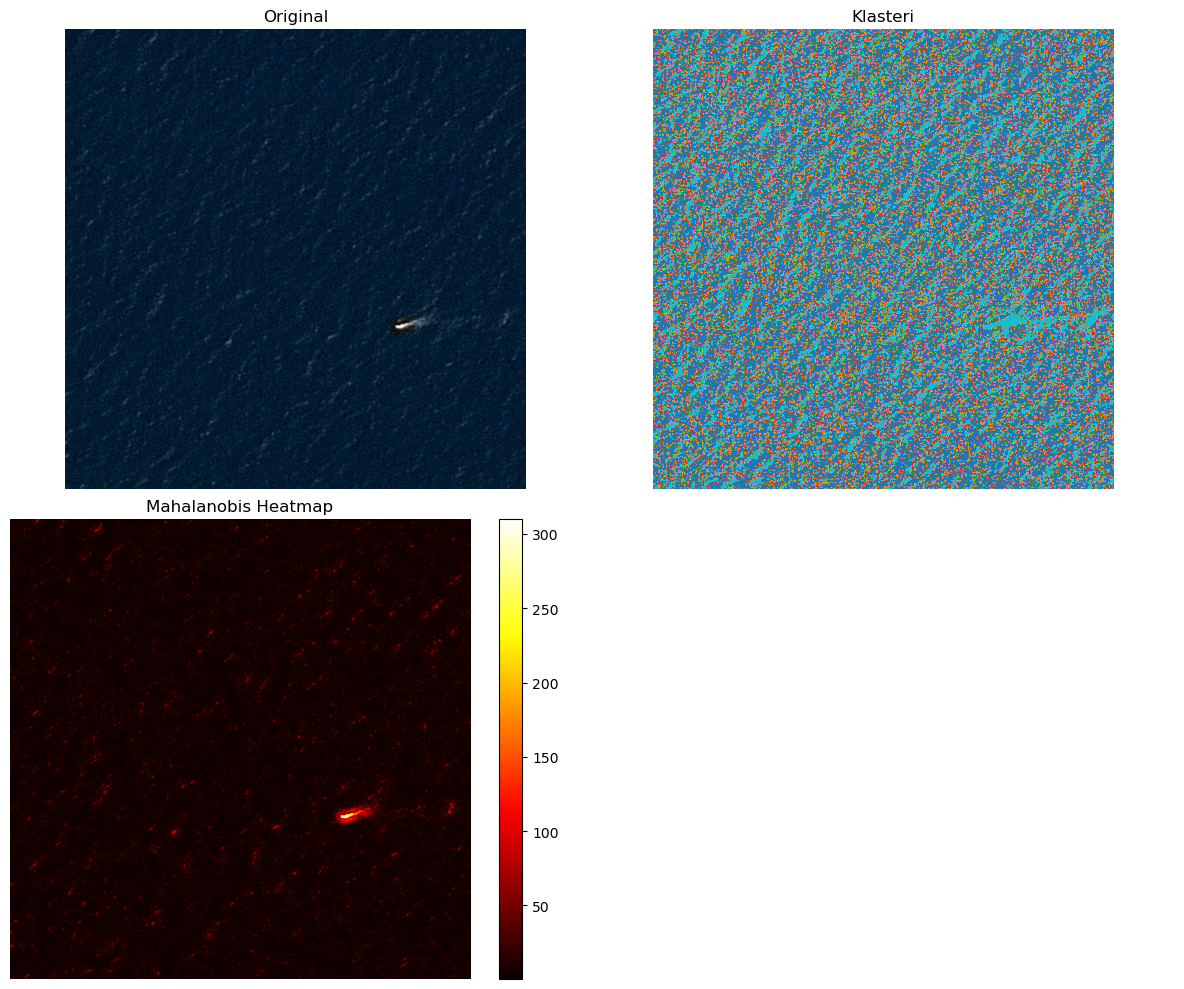

{0: {'A_c': array([[16, 36, 70],
         [ 5, 27, 56],
         [ 1, 24, 54],
         ...,
         [ 6, 28, 75],
         [ 6, 28, 75],
         [ 6, 28, 75]]),
  'B_c': array([[ 1, 25, 66],
         [ 1, 26, 70],
         [ 4, 34, 76],
         ...,
         [ 1, 33, 71],
         [ 1, 35, 73],
         [ 1, 33, 72]]),
  'mu': array([ 0.16394966, 22.72796134, 45.91030296]),
  'Sigma': array([[0.15626427, 0.23470799, 0.2477066 ],
         [0.23470799, 3.2811911 , 2.39733023],
         [0.2477066 , 2.39733023, 2.33088778]]),
  'k_hat': 0.7236403651810053,
  'theta_hat': 49.7857862834193},
 1: {'A_c': array([[ 46,  86, 112],
         [ 91, 167, 212],
         [103, 172, 245],
         ...,
         [ 47,  93, 166],
         [ 43, 102, 164],
         [ 41,  95, 169]]),
  'B_c': array([[ 42,  88, 161],
         [ 43,  92, 164],
         [ 41,  90, 162],
         ...,
         [ 43,  92, 162],
         [ 43,  92, 162],
         [ 18,  86, 152]]),
  'mu': array([ 6.04412714, 29.91450104, 

In [43]:
img = Image.open(r'C:\Users\j25tu\Downloads\Ships\020a5f9f6.jpg')
detect(img,2)

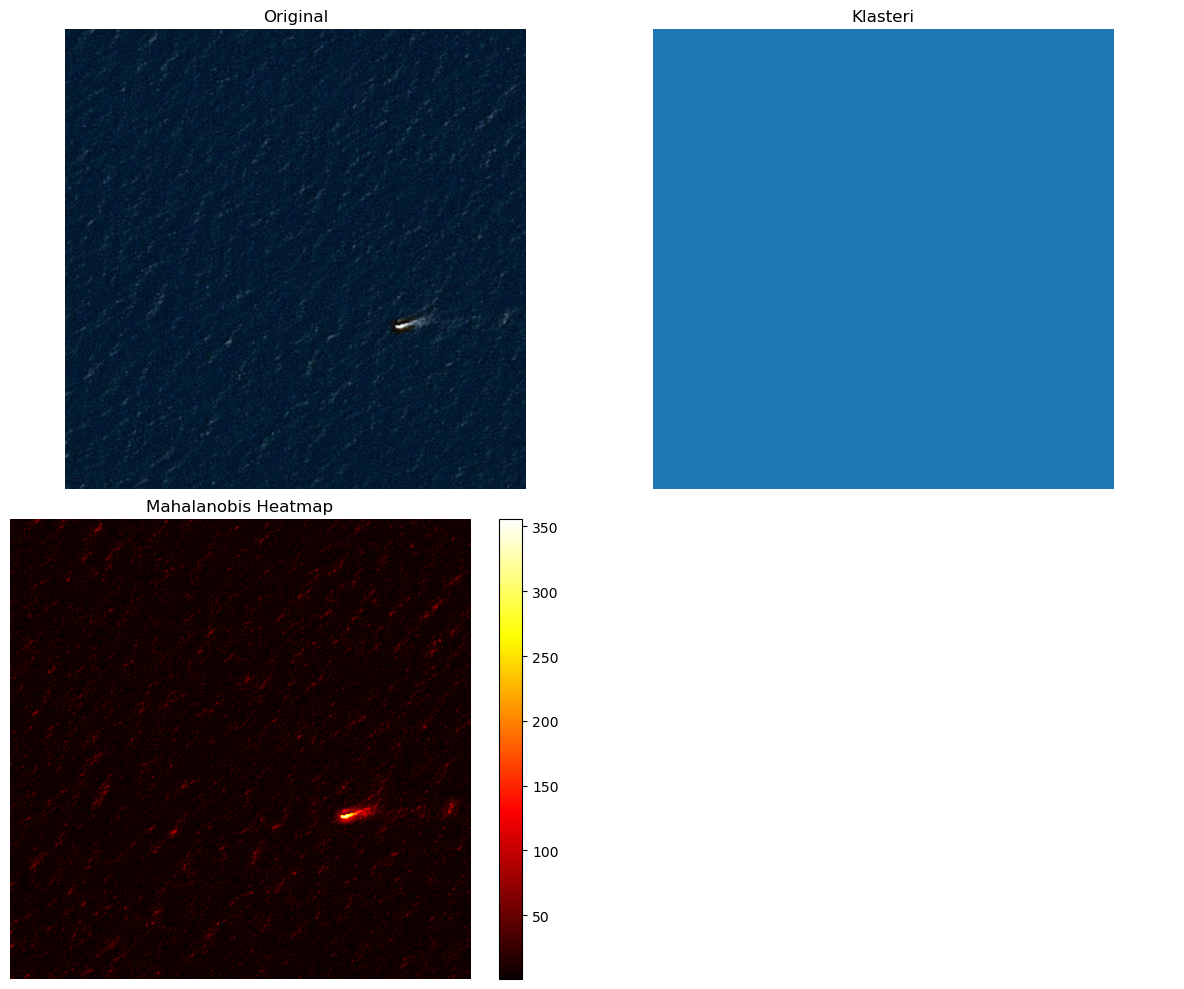

{0: {'A_c': array([[15, 31, 44],
         [11, 27, 42],
         [ 4, 20, 35],
         ...,
         [12, 40, 64],
         [12, 38, 61],
         [11, 31, 55]]),
  'B_c': array([[ 0, 18, 39],
         [ 0, 19, 42],
         [ 3, 25, 48],
         ...,
         [ 6, 31, 51],
         [ 6, 31, 51],
         [ 0, 24, 44]]),
  'mu': array([ 0.59605781, 23.60639363, 46.80499038]),
  'Sigma': array([[0.62450449, 0.93611069, 0.99008381],
         [0.93611069, 4.1623069 , 3.43885525],
         [0.99008381, 3.43885525, 3.48692787]]),
  'k_hat': 0.7695370624895956,
  'theta_hat': 50.614757728850165}}

In [44]:
img = Image.open(r'C:\Users\j25tu\Downloads\Ships\020a5f9f6.jpg')
detect(img,1)

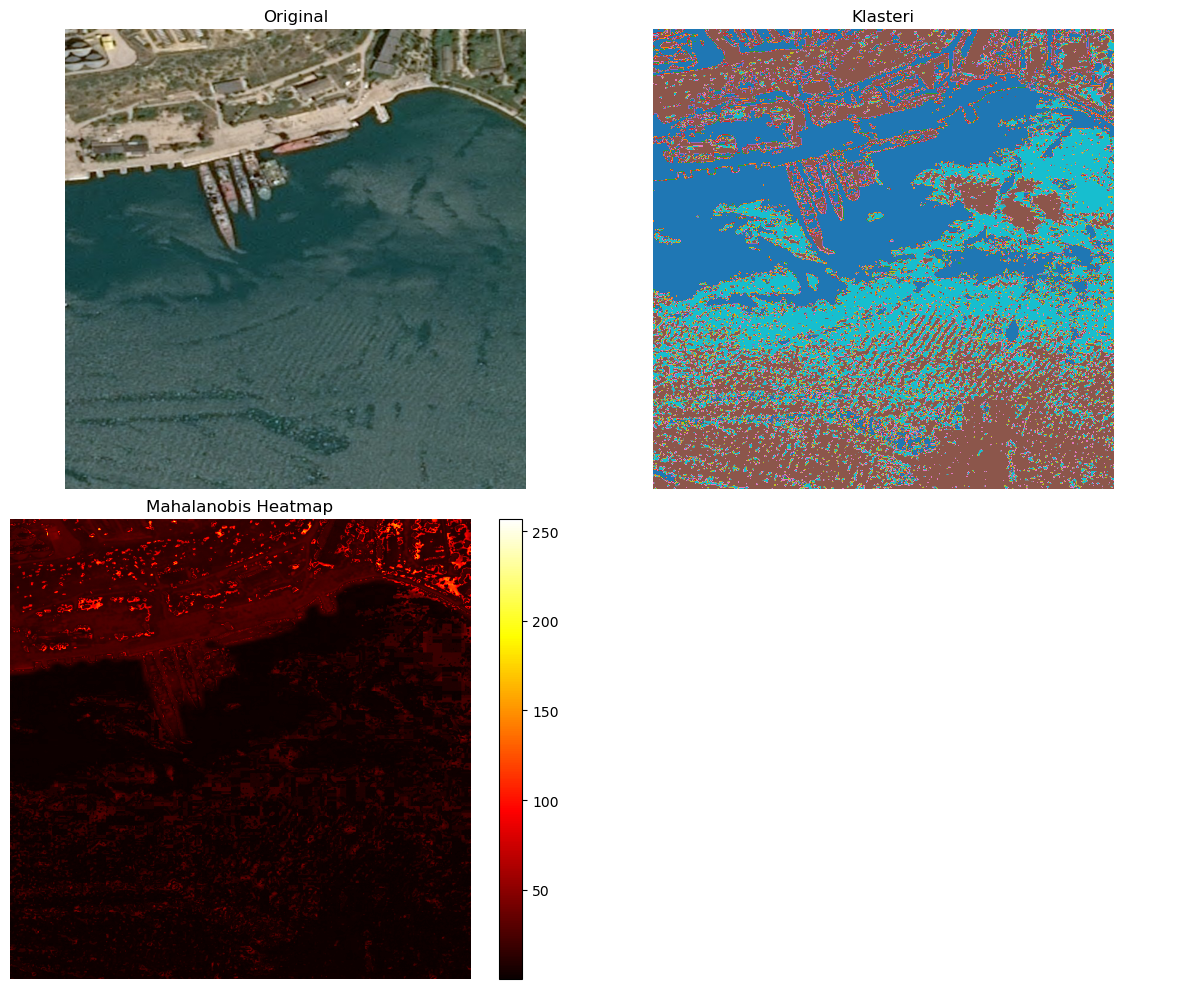

{0: {'A_c': array([[159, 134,  56],
         [141, 122,  18],
         [128,  82,   7],
         ...,
         [ 13,  56,  19],
         [ 19,  63,  51],
         [215, 273, 275]]),
  'B_c': array([[317, 319, 300],
         [308, 316, 281],
         [308, 315, 280],
         ...,
         [ 70, 134, 126],
         [ 75, 135,  95],
         [ 80, 149, 125]]),
  'mu': array([29.18395405, 70.01082693, 69.21034204]),
  'Sigma': array([[55.43727469, 29.00462619, 23.3168226 ],
         [29.00462619, 20.27787735, 18.01761833],
         [23.3168226 , 18.01761833, 19.3739155 ]]),
  'k_hat': 0.28419340115566805,
  'theta_hat': 554.3865912106512},
 1: {'A_c': array([[246, 311, 240],
         [287, 323, 243],
         [233, 191, 111],
         ...,
         [285, 231, 116],
         [283, 225, 112],
         [282, 224, 111]]),
  'B_c': array([[337, 310, 242],
         [288, 246, 228],
         [309, 285, 233],
         ...,
         [163, 233, 230],
         [161, 231, 228],
         [148, 228, 22

In [42]:
img = Image.open(r'C:\Users\j25tu\Downloads\Ships\00e5fb033.jpg')
detect(img,3)

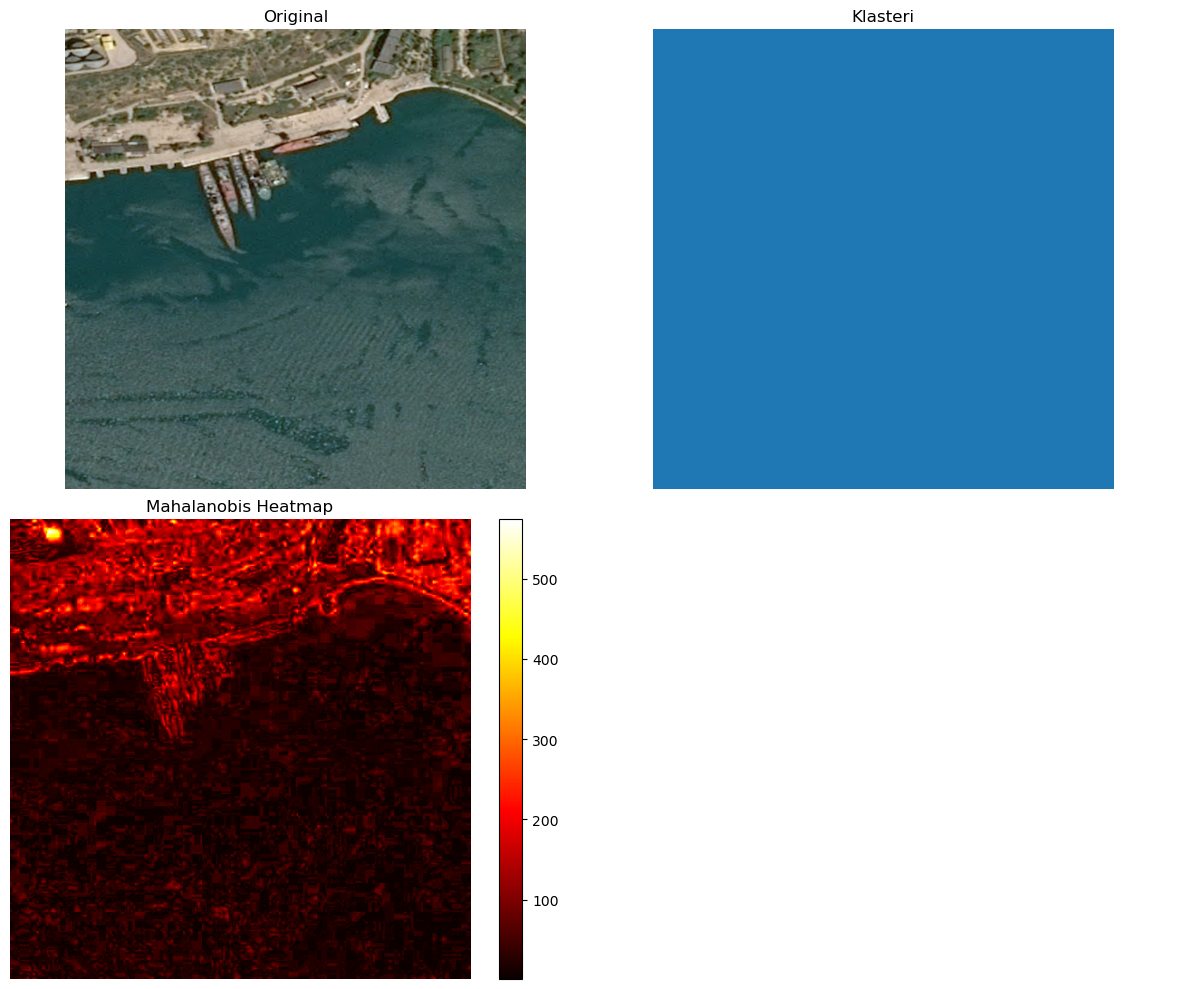

{0: {'A_c': array([[ 83,  70,  25],
         [ 72,  59,  14],
         [ 64,  51,   7],
         ...,
         [ 59,  80,  81],
         [103, 134, 129],
         [ 59,  80,  81]]),
  'B_c': array([[126, 117, 100],
         [139, 130, 115],
         [151, 139, 125],
         ...,
         [ 74, 100,  97],
         [ 72,  98,  95],
         [ 69,  95,  92]]),
  'mu': array([66.27188703, 93.56051088, 91.05190104]),
  'Sigma': array([[36.55821957, 23.8903211 , 21.01759899],
         [23.8903211 , 15.90301225, 14.13371195],
         [21.01759899, 14.13371195, 12.63858249]]),
  'k_hat': 0.5865404954932814,
  'theta_hat': 1357.3912749364977}}

In [45]:
img = Image.open(r'C:\Users\j25tu\Downloads\Ships\00e5fb033.jpg')
detect(img,1)

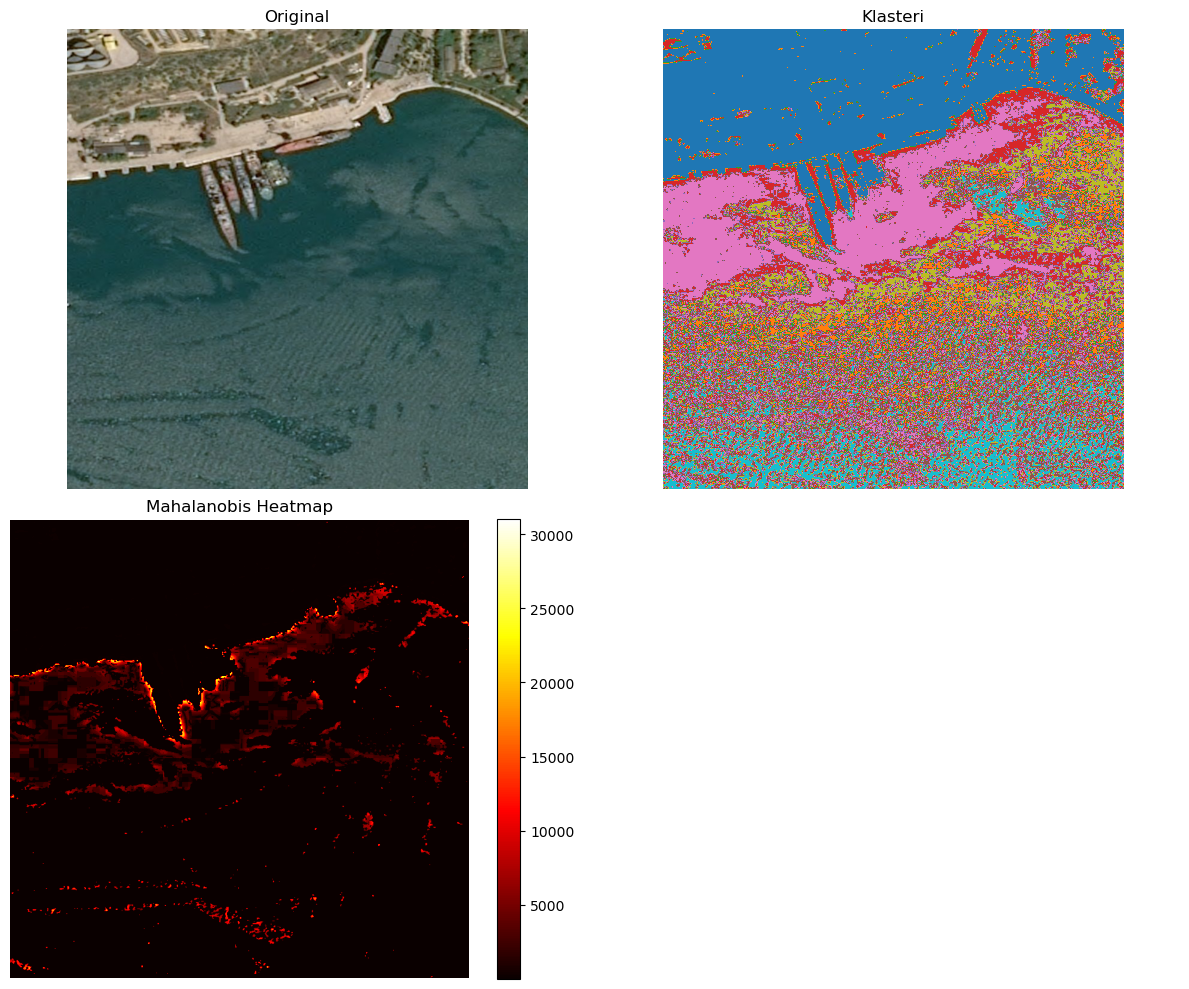

{0: {'A_c': array([[112, 135, 109],
         [125, 145, 120],
         [121, 141, 116],
         ...,
         [ 75,  84,  53],
         [ 81,  88,  54],
         [ 81,  88,  54]]),
  'B_c': array([[177, 174, 157],
         [169, 166, 147],
         [154, 149, 130],
         ...,
         [ 70,  67,  46],
         [ 89,  86,  69],
         [ 80,  79,  59]]),
  'mu': array([192.65134752, 176.37136824, 158.51056033]),
  'Sigma': array([[106.92977695,  94.72073906,  93.96418271],
         [ 94.72073906,  84.82668919,  84.64643971],
         [ 93.96418271,  84.64643971,  87.58236362]]),
  'k_hat': 1.0969302769676768,
  'theta_hat': 88.88274397150583},
 1: {'A_c': array([[ 9853, 11383,  9088],
         [ 9852, 11437,  9854],
         [ 9856, 10667,  9837],
         ...,
         [ 9084, 11375, 11384],
         [ 9084, 11375, 11384],
         [ 9084, 11375, 11384]]),
  'B_c': array([[ 8318, 11376, 10674],
         [ 8317, 11384, 11383],
         [ 8317, 11384, 11383],
         ...,
         

In [46]:
img = Image.open(r'C:\Users\j25tu\Downloads\Ships\00e5fb033.jpg')
detect(img,7)